# Home Credit Default Risk — Notebook 2  
## Logistic Regression with External Features

This notebook extends the earlier application-level logistic model by merging in the customer-level external features prepared in **Notebook 1**.

### Modelling goal
Keep the workflow close to the original notebook:
1. build clear domain features
2. explore missingness and target balance
3. run correlation filtering
4. run RFECV feature selection
5. fit logistic regression
6. review ROC AUC and coefficient direction

### Comparison view
This notebook is structured to compare two models:

- **Baseline model** — application-level variables close to the earlier notebook
- **Enhanced model** — baseline variables plus external aggregated features from bureau and behavioural datasets

That makes the improvement story much easier to explain in a portfolio or interview.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)

DATA_DIR = Path("../data/raw")

PROCESSED_DIR = Path("../data/processed")

print("Data directory:", DATA_DIR.resolve())
print("Processed directory:", PROCESSED_DIR.resolve())


Data directory: D:\Jane\Job Search\Github\bank\github project\scorecard pd ead consummer credit\data\raw
Processed directory: D:\Jane\Job Search\Github\bank\github project\scorecard pd ead consummer credit\data\processed


## 1. Helper functions


In [2]:
def safe_divide(numerator, denominator):
    if isinstance(denominator, pd.Series):
        denominator = denominator.replace(0, np.nan)
    elif denominator == 0:
        denominator = np.nan
    return numerator / denominator


def missing_summary(df: pd.DataFrame, top_n: int = 20) -> pd.DataFrame:
    out = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "n_unique": df.nunique(dropna=True).values
    }).sort_values(["missing_pct", "n_unique"], ascending=[False, False])
    return out.head(top_n)


def build_application_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["DAYS_EMPLOYED"] = pd.to_numeric(df["DAYS_EMPLOYED"], errors="coerce")
    df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

    df["DTI"] = safe_divide(df["AMT_CREDIT"], df["AMT_INCOME_TOTAL"])
    df["INST_TO_INCOME"] = safe_divide(df["AMT_ANNUITY"], df["AMT_INCOME_TOTAL"])
    df["LTV_PROXY"] = safe_divide(df["AMT_CREDIT"], df["AMT_GOODS_PRICE"])
    df["AGE"] = -df["DAYS_BIRTH"] / 365
    df["EMPLOYMENT_YEARS"] = -df["DAYS_EMPLOYED"] / 365
    df["ANNUITY_TO_CREDIT"] = safe_divide(df["AMT_ANNUITY"], df["AMT_CREDIT"])
    df["INCOME_PER_CHILD"] = safe_divide(df["AMT_INCOME_TOTAL"], df["CNT_CHILDREN"] + 1)
    df["EMPLOYED_TO_AGE_RATIO"] = safe_divide(df["EMPLOYMENT_YEARS"], df["AGE"])

    return df


def correlation_filter(X_train: pd.DataFrame, threshold: float = 0.80):
    corr_matrix = X_train.corr().abs()
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    high_corr_pairs = []
    for col in upper_triangle.columns:
        for row in upper_triangle.index:
            corr_value = upper_triangle.loc[row, col]
            if pd.notnull(corr_value) and corr_value > threshold:
                high_corr_pairs.append((row, col, corr_value))

    high_corr_df = (
        pd.DataFrame(high_corr_pairs, columns=["feature_1", "feature_2", "abs_corr"])
        .sort_values("abs_corr", ascending=False)
        .reset_index(drop=True)
        if high_corr_pairs
        else pd.DataFrame(columns=["feature_1", "feature_2", "abs_corr"])
    )

    to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > threshold)]
    return corr_matrix, high_corr_df, to_drop


def run_logistic_workflow(df: pd.DataFrame, features: list, target: str = "TARGET", random_state: int = 42):
    features = [f for f in features if f in df.columns]
    model_df = df[features + [target]].copy()

    X = model_df[features]
    y = model_df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.30,
        random_state=random_state,
        stratify=y
    )

    train_medians = X_train.median(numeric_only=True)
    X_train = X_train.fillna(train_medians)
    X_test = X_test.fillna(train_medians)

    corr_matrix, high_corr_df, to_drop_corr = correlation_filter(X_train, threshold=0.80)
    features_after_corr = [col for col in X_train.columns if col not in to_drop_corr]

    X_train_corr = X_train[features_after_corr].copy()
    X_test_corr = X_test[features_after_corr].copy()

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_corr)
    X_test_scaled = scaler.transform(X_test_corr)

    log_reg = LogisticRegression(max_iter=2000, solver="liblinear")
    rfecv = RFECV(
        estimator=log_reg,
        step=1,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state),
        scoring="roc_auc",
        min_features_to_select=5,
        n_jobs=-1
    )
    rfecv.fit(X_train_scaled, y_train)

    selected_features = X_train_corr.columns[rfecv.support_].tolist()

    X_train_final = X_train_corr[selected_features].copy()
    X_test_final = X_test_corr[selected_features].copy()

    scaler_final = StandardScaler()
    X_train_final_scaled = scaler_final.fit_transform(X_train_final)
    X_test_final_scaled = scaler_final.transform(X_test_final)

    final_model = LogisticRegression(max_iter=2000, solver="liblinear")
    final_model.fit(X_train_final_scaled, y_train)

    y_pred_proba = final_model.predict_proba(X_test_final_scaled)[:, 1]
    auc_value = roc_auc_score(y_test, y_pred_proba)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

    rfecv_scores = pd.DataFrame({
        "num_features": range(1, len(rfecv.cv_results_["mean_test_score"]) + 1),
        "mean_auc": rfecv.cv_results_["mean_test_score"]
    })

    coef_table = pd.DataFrame({
        "feature": selected_features,
        "coefficient": final_model.coef_[0]
    })
    coef_table["odds_ratio"] = np.exp(coef_table["coefficient"])
    coef_table["direction"] = np.where(
        coef_table["coefficient"] > 0,
        "Higher default risk",
        "Lower default risk"
    )
    coef_table = coef_table.sort_values("odds_ratio", ascending=False).reset_index(drop=True)

    return {
        "features_used": features,
        "n_features_input": len(features),
        "to_drop_corr": to_drop_corr,
        "features_after_corr": features_after_corr,
        "selected_features": selected_features,
        "n_selected": len(selected_features),
        "corr_matrix": corr_matrix,
        "high_corr_df": high_corr_df,
        "rfecv_scores": rfecv_scores,
        "coef_table": coef_table,
        "auc": auc_value,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds
    }


## 2. Load the modelling data


In [3]:
app_train = pd.read_csv(DATA_DIR / "application_train.csv")
external_features = pd.read_csv(PROCESSED_DIR / "home_credit_external_features.csv")

print("application_train:", app_train.shape)
print("external_features:", external_features.shape)

df = app_train.merge(external_features, on="SK_ID_CURR", how="left")
df = build_application_features(df)

print("merged modelling table:", df.shape)
df.head()


application_train: (307511, 122)
external_features: (356255, 85)


merged modelling table: (307511, 214)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,BUREAU_COUNT,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_ENDDATE_MAX,BUREAU_DAYS_ENDDATE_FACT_MAX,BUREAU_AMT_CREDIT_SUM_SUM,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM,BUREAU_AMT_ANNUITY_MEAN,BUREAU_CNT_CREDIT_PROLONG_SUM,BUREAU_DEBT_TO_CREDIT_RATIO_MEAN,BUREAU_DEBT_TO_CREDIT_RATIO_MAX,BUREAU_OVERDUE_TO_DEBT_RATIO_MEAN,BUREAU_IS_ACTIVE_SUM,BUREAU_IS_ACTIVE_MEAN,BUREAU_IS_CLOSED_SUM,BUREAU_IS_CONSUMER_CREDIT_MEAN,BUREAU_IS_CREDIT_CARD_MEAN,BUREAU_BB_RECORD_COUNT_SUM,BUREAU_BB_STATUS_MEAN_MEAN,BUREAU_BB_STATUS_MAX_MAX,BUREAU_BB_DPD_RATE_MEAN,BUREAU_BB_SEVERE_DPD_RATE_MEAN,PREV_COUNT,PREV_AMT_APPLICATION_MEAN,PREV_AMT_CREDIT_MEAN,PREV_AMT_CREDIT_SUM,PREV_AMT_ANNUITY_MEAN,PREV_APP_CREDIT_PCT_MEAN,PREV_APP_CREDIT_PCT_MAX,PREV_DOWNPAYMENT_TO_CREDIT_MEAN,PREV_GOODS_TO_CREDIT_MEAN,PREV_RATE_DOWN_PAYMENT_MEAN,PREV_CNT_PAYMENT_MEAN,PREV_CNT_PAYMENT_MAX,PREV_DAYS_DECISION_MAX,PREV_DAYS_DECISION_MEAN,PREV_IS_APPROVED_SUM,PREV_IS_APPROVED_MEAN,PREV_IS_REFUSED_SUM,PREV_IS_REFUSED_MEAN,PREV_IS_CANCELED_MEAN,PREV_IS_UNUSED_OFFER_MEAN,POS_COUNT,POS_MONTHS_BALANCE_MIN,POS_MONTHS_BALANCE_MAX,POS_CNT_INSTALMENT_MEAN,POS_CNT_INSTALMENT_FUTURE_MEAN,POS_SK_DPD_MEAN,POS_SK_DPD_MAX,POS_SK_DPD_DEF_MEAN,POS_SK_DPD_DEF_MAX,POS_IS_COMPLETED_MEAN,POS_IS_ACTIVE_MEAN,POS_IS_SIGNED_MEAN,INSTAL_COUNT,INSTAL_PAYMENT_RATIO_MEAN,INSTAL_PAYMENT_RATIO_MIN,INSTAL_PAYMENT_SHORTFALL_SUM,INSTAL_DPD_MEAN,INSTAL_DPD_MAX,INSTAL_DBD_MEAN,INSTAL_IS_LATE_MEAN,INSTAL_IS_UNDERPAID_MEAN,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_INSTALMENT_MEAN,CC_COUNT,CC_MONTHS_BALANCE_MIN,CC_MONTHS_BALANCE_MAX,CC_AMT_BALANCE_MEAN,CC_AMT_BALANCE_SUM,CC_AMT_CREDIT_LIMIT_ACTUAL_MAX,CC_UTILIZATION_MEAN,CC_UTILIZATION_MAX,CC_DRAWINGS_TO_LIMIT_RATIO_MEAN,CC_PAYMENT_TO_MIN_RATIO_MEAN,CC_SK_DPD_MEAN,CC_SK_DPD_MAX,CC_SK_DPD_DEF_MAX,CC_IS_DELAYED_MEAN,CC_CNT_DRAWINGS_CURRENT_MEAN,DTI,INST_TO_INCOME,LTV_PROXY,AGE,EMPLOYMENT_YEARS,ANNUITY_TO_CREDIT,INCOME

## 3. Quick exploration

This section mirrors the original workflow by checking:
- class imbalance
- missingness
- a first look at the merged table


In [4]:
target_count = df["TARGET"].value_counts().sort_index()
target_ratio = df["TARGET"].value_counts(normalize=True).sort_index()

print("Target count:")
print(target_count)
print()
print("Target ratio:")
print(target_ratio)


Target count:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target ratio:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [5]:
summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null_count": df.notnull().sum().values,
    "missing_pct": (df.isnull().mean().values * 100).round(2)
}).sort_values("missing_pct", ascending=False)

summary.head(20)


,column,dtype,non_null_count,missing_pct
200,CC_PAYMENT_TO_MIN_RATIO_MEAN,float64,59269,80.73
133,BUREAU_AMT_ANNUITY_MEAN,float64,80009,73.98
197,CC_UTILIZATION_MEAN,float64,86036,72.02
199,CC_DRAWINGS_TO_LIMIT_RATIO_MEAN,float64,86036,72.02
198,CC_UTILIZATION_MAX,float64,86036,72.02
205,CC_CNT_DRAWINGS_CURRENT_MEAN,float64,86905,71.74
202,CC_SK_DPD_MAX,float64,86905,71.74
194,CC_AMT_BALANCE_MEAN,float64,86905,71.74
192,CC_MONTHS_BALANCE_MIN,float64,86905,71.74
191,CC_COUNT,float64,86905,71.74


## 4. Candidate feature sets

### Baseline feature set
This keeps the spirit of the earlier application-level notebook:
- income
- credit amount
- annuity burden
- leverage proxy
- age and employment stability
- external bureau-style scores already present in the application file

### Enhanced feature set
This adds customer-level aggregates from the other Home Credit tables.


In [6]:
baseline_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DTI",
    "INST_TO_INCOME",
    "LTV_PROXY",
    "AGE",
    "EMPLOYMENT_YEARS",
    "CNT_CHILDREN",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "ANNUITY_TO_CREDIT",
    "INCOME_PER_CHILD",
    "EMPLOYED_TO_AGE_RATIO"
]

external_features_curated = [
    "BUREAU_COUNT",
    "BUREAU_AMT_CREDIT_SUM_SUM",
    "BUREAU_AMT_CREDIT_SUM_DEBT_SUM",
    "BUREAU_DEBT_TO_CREDIT_RATIO_MEAN",
    "BUREAU_OVERDUE_TO_DEBT_RATIO_MEAN",
    "BUREAU_IS_ACTIVE_SUM",
    "BUREAU_BB_DPD_RATE_MEAN",
    "BUREAU_BB_SEVERE_DPD_RATE_MEAN",
    "PREV_COUNT",
    "PREV_APP_CREDIT_PCT_MEAN",
    "PREV_AMT_CREDIT_MEAN",
    "PREV_IS_APPROVED_MEAN",
    "PREV_IS_REFUSED_MEAN",
    "POS_COUNT",
    "POS_SK_DPD_MAX",
    "POS_SK_DPD_DEF_MAX",
    "POS_IS_COMPLETED_MEAN",
    "INSTAL_COUNT",
    "INSTAL_PAYMENT_RATIO_MEAN",
    "INSTAL_PAYMENT_SHORTFALL_SUM",
    "INSTAL_DPD_MEAN",
    "INSTAL_DPD_MAX",
    "INSTAL_IS_LATE_MEAN",
    "INSTAL_IS_UNDERPAID_MEAN",
    "CC_COUNT",
    "CC_AMT_BALANCE_SUM",
    "CC_UTILIZATION_MEAN",
    "CC_UTILIZATION_MAX",
    "CC_PAYMENT_TO_MIN_RATIO_MEAN",
    "CC_SK_DPD_MAX"
]

enhanced_features = baseline_features + external_features_curated

print("Baseline features available:", [f for f in baseline_features if f in df.columns])
print()
print("External features available:", [f for f in external_features_curated if f in df.columns])


Baseline features available: ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DTI', 'INST_TO_INCOME', 'LTV_PROXY', 'AGE', 'EMPLOYMENT_YEARS', 'CNT_CHILDREN', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'ANNUITY_TO_CREDIT', 'INCOME_PER_CHILD', 'EMPLOYED_TO_AGE_RATIO']

External features available: ['BUREAU_COUNT', 'BUREAU_AMT_CREDIT_SUM_SUM', 'BUREAU_AMT_CREDIT_SUM_DEBT_SUM', 'BUREAU_DEBT_TO_CREDIT_RATIO_MEAN', 'BUREAU_OVERDUE_TO_DEBT_RATIO_MEAN', 'BUREAU_IS_ACTIVE_SUM', 'BUREAU_BB_DPD_RATE_MEAN', 'BUREAU_BB_SEVERE_DPD_RATE_MEAN', 'PREV_COUNT', 'PREV_APP_CREDIT_PCT_MEAN', 'PREV_AMT_CREDIT_MEAN', 'PREV_IS_APPROVED_MEAN', 'PREV_IS_REFUSED_MEAN', 'POS_COUNT', 'POS_SK_DPD_MAX', 'POS_SK_DPD_DEF_MAX', 'POS_IS_COMPLETED_MEAN', 'INSTAL_COUNT', 'INSTAL_PAYMENT_RATIO_MEAN', 'INSTAL_PAYMENT_SHORTFALL_SUM', 'INSTAL_DPD_MEAN', 'INSTAL_DPD_MAX', 'INSTAL_IS_LATE_MEAN', 'INSTAL_IS_UNDERPAID_MEAN', 'CC_COUNT', 'CC_AMT_BALANCE_SUM', 'CC_UTILIZATION_MEAN', 'CC_UTILIZATION_MAX', 'CC_PAYMENT_TO_MIN_RATIO_MEAN', 'CC_S

## 5. Exploratory correlation review for the enhanced feature pool


In [7]:
candidate_features = [f for f in enhanced_features if f in df.columns]
corr_input = df[candidate_features + ["TARGET"]].copy()

for col in candidate_features:
    corr_input[col] = corr_input[col].fillna(corr_input[col].median())

feature_target_corr = (
    corr_input[candidate_features + ["TARGET"]]
    .corr()["TARGET"]
    .drop("TARGET")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("corr_with_target")
)

feature_target_corr.head(20)


,corr_with_target
EXT_SOURCE_2,-0.160295
EXT_SOURCE_3,-0.155892
AGE,-0.078239
PREV_IS_REFUSED_MEAN,0.077894
CC_UTILIZATION_MEAN,0.075047
INSTAL_IS_LATE_MEAN,0.070190
LTV_PROXY,0.069398
EMPLOYMENT_YEARS,-0.063368
INSTAL_IS_UNDERPAID_MEAN,0.063136
PREV_IS_APPROVED_MEAN,-0.062983


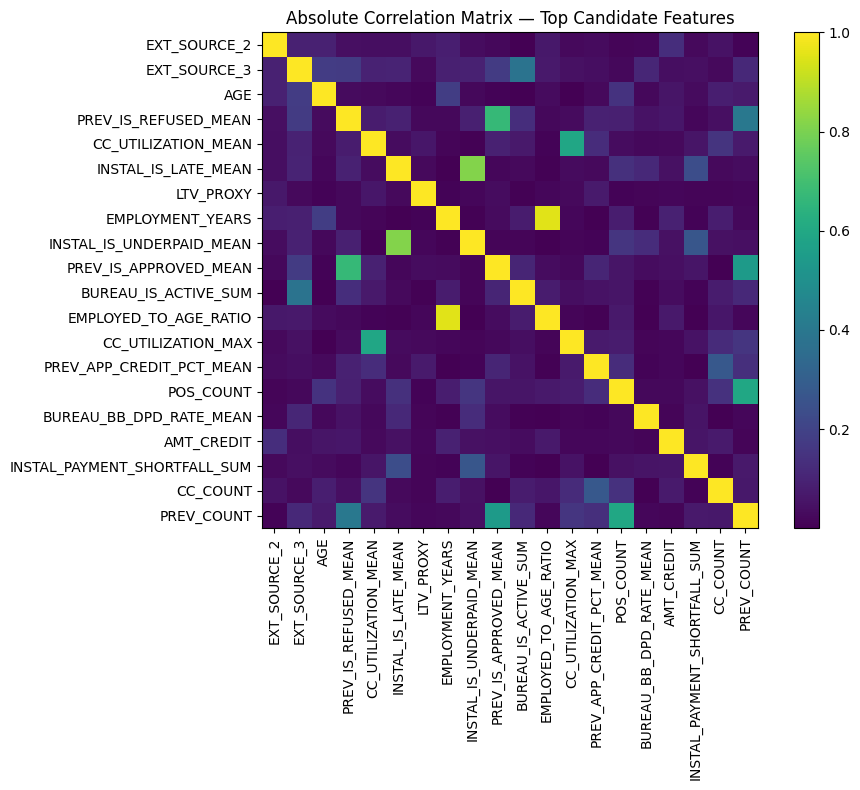

In [8]:
top_corr_features = feature_target_corr.head(20).index.tolist()

plt.figure(figsize=(10, 8))
plt.imshow(corr_input[top_corr_features].corr().abs(), interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(top_corr_features)), top_corr_features, rotation=90)
plt.yticks(range(len(top_corr_features)), top_corr_features)
plt.title("Absolute Correlation Matrix — Top Candidate Features")
plt.tight_layout()
plt.show()


## 6. Run the baseline logistic workflow


In [9]:
baseline_results = run_logistic_workflow(df, baseline_features, target="TARGET", random_state=42)

pd.DataFrame({
    "metric": [
        "Input features",
        "Dropped by correlation filter",
        "Features after correlation filter",
        "RFECV-selected features",
        "Test ROC AUC"
    ],
    "value": [
        baseline_results["n_features_input"],
        len(baseline_results["to_drop_corr"]),
        len(baseline_results["features_after_corr"]),
        baseline_results["n_selected"],
        round(baseline_results["auc"], 4)
    ]
})


,metric,value
0,Input features,14.0000
1,Dropped by correlation filter,2.0000
2,Features after correlation filter,12.0000
3,RFECV-selected features,12.0000
4,Test ROC AUC,0.7252


In [10]:
baseline_results["high_corr_df"].head(20)


,feature_1,feature_2,abs_corr
0,EMPLOYMENT_YEARS,EMPLOYED_TO_AGE_RATIO,0.955248
1,AMT_INCOME_TOTAL,INCOME_PER_CHILD,0.925538


In [11]:
baseline_results["rfecv_scores"].head(20)


,num_features,mean_auc
0,1,0.720148
1,2,0.721012
2,3,0.722966
3,4,0.723047
4,5,0.723090
5,6,0.723413
6,7,0.723415
7,8,0.723426


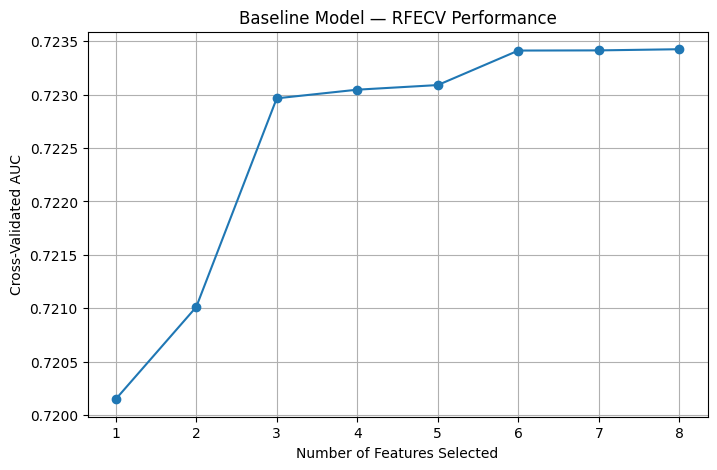

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(
    baseline_results["rfecv_scores"]["num_features"],
    baseline_results["rfecv_scores"]["mean_auc"],
    marker="o"
)
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validated AUC")
plt.title("Baseline Model — RFECV Performance")
plt.grid(True)
plt.show()


In [13]:
baseline_results["coef_table"]


,feature,coefficient,odds_ratio,direction
0,INST_TO_INCOME,0.220248,1.246386,Higher default risk
1,LTV_PROXY,0.191498,1.211062,Higher default risk
2,AMT_ANNUITY,0.099820,1.104972,Higher default risk
3,AMT_INCOME_TOTAL,0.015571,1.015693,Higher default risk
4,CNT_CHILDREN,-0.007774,0.992256,Lower default risk
5,ANNUITY_TO_CREDIT,-0.119193,0.887636,Lower default risk
6,AGE,-0.139383,0.869895,Lower default risk
7,DTI,-0.144982,0.865038,Lower default risk
8,AMT_CREDIT,-0.158522,0.853404,Lower default risk
9,EMPLOYMENT_YEARS,-0.175442,0.839086,Lower default risk


## 7. Run the enhanced logistic workflow


In [14]:
enhanced_results = run_logistic_workflow(df, enhanced_features, target="TARGET", random_state=42)

pd.DataFrame({
    "metric": [
        "Input features",
        "Dropped by correlation filter",
        "Features after correlation filter",
        "RFECV-selected features",
        "Test ROC AUC"
    ],
    "value": [
        enhanced_results["n_features_input"],
        len(enhanced_results["to_drop_corr"]),
        len(enhanced_results["features_after_corr"]),
        enhanced_results["n_selected"],
        round(enhanced_results["auc"], 4)
    ]
})


,metric,value
0,Input features,44.0000
1,Dropped by correlation filter,3.0000
2,Features after correlation filter,41.0000
3,RFECV-selected features,27.0000
4,Test ROC AUC,0.7437


In [15]:
enhanced_results["high_corr_df"].head(25)


,feature_1,feature_2,abs_corr
0,EMPLOYMENT_YEARS,EMPLOYED_TO_AGE_RATIO,0.955248
1,AMT_INCOME_TOTAL,INCOME_PER_CHILD,0.925538
2,INSTAL_IS_LATE_MEAN,INSTAL_IS_UNDERPAID_MEAN,0.813148


In [16]:
enhanced_results["rfecv_scores"].head(25)


,num_features,mean_auc
0,1,0.716174
1,2,0.719379
2,3,0.724721
3,4,0.729358
4,5,0.732412
5,6,0.734780
6,7,0.736239
7,8,0.737248
8,9,0.738460
9,10,0.738882


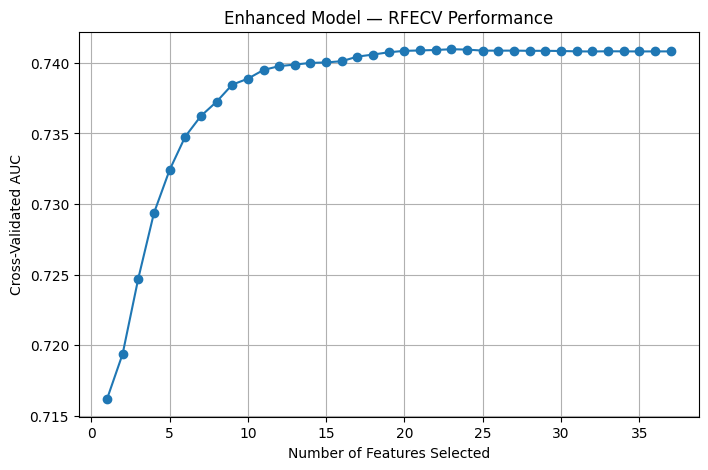

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(
    enhanced_results["rfecv_scores"]["num_features"],
    enhanced_results["rfecv_scores"]["mean_auc"],
    marker="o"
)
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validated AUC")
plt.title("Enhanced Model — RFECV Performance")
plt.grid(True)
plt.show()


In [18]:
enhanced_results["coef_table"]


,feature,coefficient,odds_ratio,direction
0,INST_TO_INCOME,0.211541,1.235581,Higher default risk
1,BUREAU_IS_ACTIVE_SUM,0.179786,1.196962,Higher default risk
2,LTV_PROXY,0.166660,1.181353,Higher default risk
3,INSTAL_IS_LATE_MEAN,0.155454,1.168188,Higher default risk
4,CC_UTILIZATION_MEAN,0.150108,1.161959,Higher default risk
5,PREV_IS_REFUSED_MEAN,0.104737,1.110419,Higher default risk
6,AMT_ANNUITY,0.096927,1.101780,Higher default risk
7,PREV_COUNT,0.066693,1.068967,Higher default risk
8,CC_UTILIZATION_MAX,0.052354,1.053749,Higher default risk
9,INSTAL_PAYMENT_SHORTFALL_SUM,0.037216,1.037917,Higher default risk


## 8. Compare ROC curves


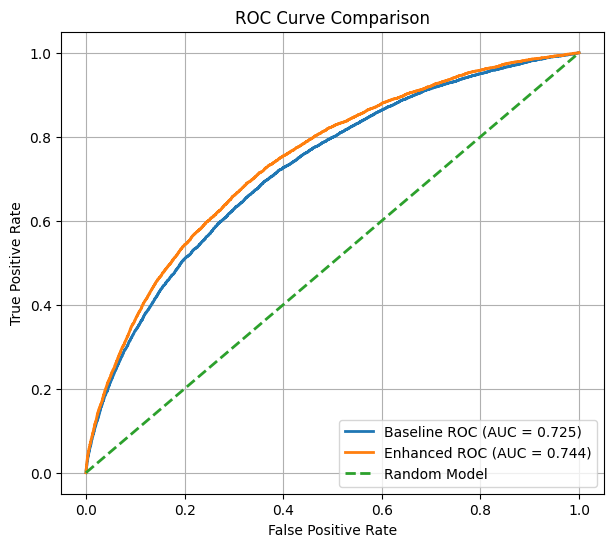

In [19]:
plt.figure(figsize=(7, 6))

plt.plot(
    baseline_results["fpr"],
    baseline_results["tpr"],
    label=f'Baseline ROC (AUC = {baseline_results["auc"]:.3f})',
    linewidth=2
)

plt.plot(
    enhanced_results["fpr"],
    enhanced_results["tpr"],
    label=f'Enhanced ROC (AUC = {enhanced_results["auc"]:.3f})',
    linewidth=2
)

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [20]:
comparison = pd.DataFrame({
    "model": ["Baseline application model", "Enhanced model with external aggregates"],
    "roc_auc": [baseline_results["auc"], enhanced_results["auc"]],
    "n_selected_features": [baseline_results["n_selected"], enhanced_results["n_selected"]]
})

comparison["auc_lift_vs_baseline"] = comparison["roc_auc"] - comparison["roc_auc"].iloc[0]
comparison


,model,roc_auc,n_selected_features,auc_lift_vs_baseline
0,Baseline application model,0.725226,12,0.000000
1,Enhanced model with external aggregates,0.743725,27,0.018499


## 9. Review the selected enhanced features

This is the table most useful for a portfolio discussion because it shows **which external signals survived feature selection** and how the final logistic model interprets them.


In [21]:
pd.DataFrame({
    "selected_feature": enhanced_results["selected_features"]
})


,selected_feature
0,AMT_CREDIT
1,AMT_ANNUITY
2,DTI
3,INST_TO_INCOME
4,LTV_PROXY
5,AGE
6,EMPLOYMENT_YEARS
7,EXT_SOURCE_2
8,EXT_SOURCE_3
9,ANNUITY_TO_CREDIT


In [22]:
for _, row in enhanced_results["coef_table"].iterrows():
    print(f"Feature: {row['feature']}")
    print(f"Coefficient: {row['coefficient']:.4f}")
    print(f"Odds Ratio: {row['odds_ratio']:.4f}")
    print(f"Direction: {row['direction']}")
    print("-" * 60)


Feature: INST_TO_INCOME
Coefficient: 0.2115
Odds Ratio: 1.2356
Direction: Higher default risk
------------------------------------------------------------
Feature: BUREAU_IS_ACTIVE_SUM
Coefficient: 0.1798
Odds Ratio: 1.1970
Direction: Higher default risk
------------------------------------------------------------
Feature: LTV_PROXY
Coefficient: 0.1667
Odds Ratio: 1.1814
Direction: Higher default risk
------------------------------------------------------------
Feature: INSTAL_IS_LATE_MEAN
Coefficient: 0.1555
Odds Ratio: 1.1682
Direction: Higher default risk
------------------------------------------------------------
Feature: CC_UTILIZATION_MEAN
Coefficient: 0.1501
Odds Ratio: 1.1620
Direction: Higher default risk
------------------------------------------------------------
Feature: PREV_IS_REFUSED_MEAN
Coefficient: 0.1047
Odds Ratio: 1.1104
Direction: Higher default risk
------------------------------------------------------------
Feature: AMT_ANNUITY
Coefficient: 0.0969
Odds Ratio: 

## 10. Interpretation guide

When you run this notebook on the full Kaggle data, the usual interpretation pattern is:

- **Repayment burden variables** often remain important  
  such as `INST_TO_INCOME`, `AMT_ANNUITY`, or instalment delinquency variables.

- **External credit exposure variables** often help  
  such as total bureau debt, overdue balances, or active-credit counts.

- **Behavioural delinquency variables** from POS, instalments, and credit card tables can add strong signal  
  because they are closer to realised repayment behaviour than static application data.

- **External score variables** like `EXT_SOURCE_2` and `EXT_SOURCE_3` are still usually strong anchors  
  even after adding the new features.

Use the final coefficient table to explain whether the enriched model behaves in line with credit-risk intuition.


## 11. Portfolio wrap-up

### What this notebook demonstrates
- you reproduced a clean scorecard-style logistic workflow
- you expanded beyond application-only variables
- you used multi-table feature engineering
- you kept the modelling explainable through correlation filtering, RFECV, ROC AUC, and coefficient review

### Good portfolio message
A strong way to describe this project is:

> Started with a baseline application-only PD model, then engineered customer-level bureau and behavioural features from the full Home Credit relational dataset, reran feature selection and logistic regression, and evaluated uplift using ROC AUC.

### Optional next step
After this notebook, a natural extension is to compare the enhanced logistic regression against:
- regularized logistic regression
- weight of evidence / binning style scorecard transformation
- tree-based models such as LightGBM
